# 4.1. Model white-noise Spikey light curve

This notebook is used to test the `UltraNest` modelling of the simulated light curves. It contains the following sections modelling:

- 4.1: White noise + Spikey fiducial
- 4.2: PlatoSim + Spikey fiducial

In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# Built-in
import os
import sys
import json
import copy
import datetime

# Dependencies
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

import jax
from jax import random
from jax import numpy as jnp
sys.path.append('../src')
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import NUTS, MCMC
numpyro.enable_x64()
numpyro.set_host_device_count(4)

# Internal methods
sys.path.append('../src')
from smbhb_jax import smbhb_two_masses
import smbhb as smbhb
import utils as ut
import plots as pt
import bayes as bs

# Setup matplotlibrc
pt.setup()

# Increase width of notebook
from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

I/O paths for data

In [7]:
path = Path('../')
ddir = path / 'data'
fdir = path / 'figures'
rdir = path / 'results'

First we create a time array for the model

In [8]:
tdur = 3 * ut.year2sec() / 86400 
dt   = 3
time = smbhb.time(tdur, dt)

---
## 0. Generate light curve
---

Initialise model parameters and disable AGN red noise

In [6]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM1 = logM1
params.logM2 = logM2
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = 0     # Disabling AGN red noise
params.seed  = 12345

Initialise model with model parameters:

In [7]:
model = smbhb.model(params)

Generate the light curve model:

In [8]:
dm = model.light_curve(time, df=True)

Create data frame with model time series:

In [9]:
dv = pd.DataFrame()
dv['time'] = dm.time
dv['flux'] = dm.flux

Create data frame with model components and plot it:

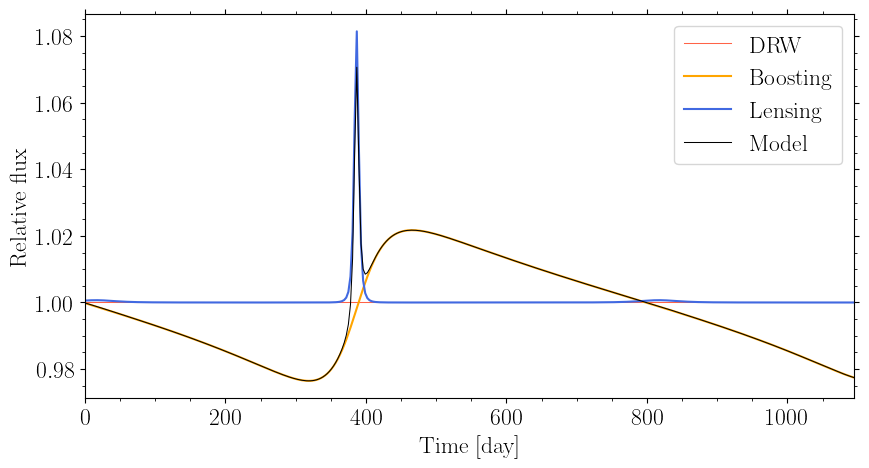

In [10]:
pt.plot_model(dm)
plt.show()

Add some Gaussian noise to to the model

In [11]:
df = dv.copy()
noise_level = 2e-3  # [pp1]
np.random.seed(seed)  # Reproducibility
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)

Plot new noisy light curve

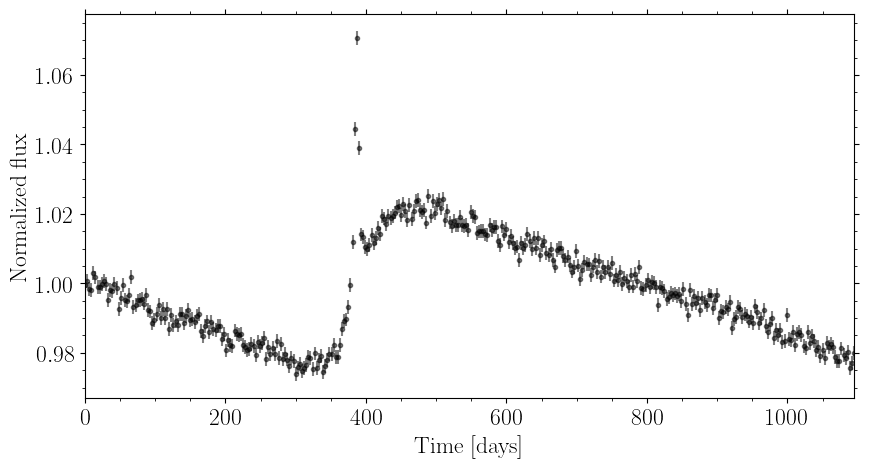

In [12]:
pt.plot_lc(df)
plt.show()

Arrays to be used for the rest of the analysis

In [8]:
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()

NameError: name 'df' is not defined

---
## 1. UltraNest with uniform priors
---

Path to save results to

In [21]:
# path = rdir / 'spikey_whitenoise_test0'

Define priors  UltraNest + SMBHB:

In [23]:
filename = 'spikey_whitenoise_test0'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [P*0.95, P*1.05]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.17 [-10336.0774..-10336.0769]*| it/evals=13930/1019223 eff=1.3673% N=400 
# [ultranest] Likelihood function evaluations: 1019640
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.2103
# [ultranest] Effective samples strategy satisfied (ESS = 3072.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.55, need <0.5)
# [ultranest]   logZ error budget: single: 0.26 bs:0.21 tail:0.01 total:0.21 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:02.164283 [h:mm:ss]

# logZ = -10366.062 +- 0.422
#   single instance: logZ = -10366.062 +- 0.257
#   bootstrapped   : logZ = -10366.086 +- 0.421
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.93% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05304│ ▁ ▁ ▁▁▁▁▁▁▂▂▂▃▄▅▆▇▆▇▇▇▆▆▅▄▃▂▁▁▁▁▁▁▁▁▁ │1.06115    1.05739 +- 0.00095
#     P                   : 1.1337│ ▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▆▆▇▇▇▇▆▇▅▄▃▂▂▂▁▁▁▁▁▁▁▁ │1.1623    1.1485 +- 0.0035
#     i                   : 81.40 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▆▆▆▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁   ▁ │83.47     82.43 +- 0.23
#     e                   : 0.5103│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁▁ │0.5511    0.5311 +- 0.0047
#     w                   : 86.67 │ ▁  ▁▁▁▁▁▁▁▁▂▂▄▄▅▆▇▇▇▇▆▆▅▅▃▃▂▁▁▁▁▁▁▁▁▁ │91.59     89.25 +- 0.58
#     logM1               : 7.072 │ ▁  ▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▃▂▂▂▁▁▁▁▁▁▁ ▁ │7.388     7.232 +- 0.035
#     logM2               : 5.00  │▃▃▃▃▃▃▃▄▃▃▃▄▃▄▄▄▄▄▅▄▄▄▅▅▅▆▇▇▅▇▇▆▅▂▁▁▁▁ │6.85      5.95 +- 0.45
#     L                   : 0.893 │ ▁▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▄▄▅▅▆▆▇│1.000     0.985 +- 0.013
#     alpha               : 1.970 │ ▁   ▁▁ ▁▁▁▁▁▁▁▁▂▃▄▅▅▆▇▇▇▇▇▆▅▄▃▂▁▁▁▁▁▁ │2.270     2.154 +- 0.033

In [93]:
filename = 'spikey_whitenoise_test1'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.14 [-10335.9528..-10335.9525]*| it/evals=15560/1116445 eff=1.3942% N=400 0 
# [ultranest] Likelihood function evaluations: 1116844
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.1789
# [ultranest] Effective samples strategy satisfied (ESS = 3125.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:26.393577 [h:mm:ss]

# logZ = -10370.030 +- 0.435
#   single instance: logZ = -10370.030 +- 0.277
#   bootstrapped   : logZ = -10370.033 +- 0.435
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.87% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05316│ ▁▁▁ ▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁ │1.06156    1.05739 +- 0.00092
#     P                   : 1.1336│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▆▆▇▇▇▇▇▅▄▃▃▂▂▁▁▁▁▁▁▁  ▁ │1.1642    1.1487 +- 0.0033
#     i                   : 81.41 │ ▁▁ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▇▇▆▆▄▃▂▂▁▁▁▁▁▁▁▁▁ │83.37     82.44 +- 0.22
#     e                   : 0.5109│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▅▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.5497    0.5312 +- 0.0045
#     w                   : 86.78 │ ▁▁ ▁▁▁▁▁▁▁▁▃▃▄▅▇▇▇▇▆▆▄▄▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │91.86     89.25 +- 0.56
#     logM1               : 7.097 │ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▆▇▇▇▇▇▇▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.365     7.230 +- 0.034
#     logM2               : 5.00  │▂▃▂▂▂▃▃▃▃▃▃▃▃▄▄▅▃▅▄▅▆▆▇▅▇▇▇▇▆▇▅▃▂▁▁▁▁▁ │6.92      5.97 +- 0.41
#     L                   : 0.899 │ ▁▁ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▅▇▇▇│1.000     0.985 +- 0.013
#     alpha               : 1.980 │ ▁  ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▇▅▅▄▃▂▂▁▁▁▁▁ │2.263     2.153 +- 0.032

In [34]:
filename = 'spikey_whitenoise_test2'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz
# [ultranest] Explored until L=-1e+04  -10335.14 [-10335.9528..-10335.9525]*| it/evals=15560/1116445 eff=1.3942% N=400 0 
# [ultranest] Likelihood function evaluations: 1116844
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.037e+04 +- 0.1789
# [ultranest] Effective samples strategy satisfied (ESS = 3125.4, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.01 total:0.18 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:04:26.393577 [h:mm:ss]

# logZ = -10370.030 +- 0.435
#   single instance: logZ = -10370.030 +- 0.277
#   bootstrapped   : logZ = -10370.033 +- 0.435
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.87% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05316│ ▁▁▁ ▁▁▁▁▁▁▁▂▃▄▅▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁▁▁ │1.06156    1.05739 +- 0.00092
#     P                   : 1.1336│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▆▆▇▇▇▇▇▅▄▃▃▂▂▁▁▁▁▁▁▁  ▁ │1.1642    1.1487 +- 0.0033
#     i                   : 81.41 │ ▁▁ ▁▁▁▁▁▁▁▁▂▂▃▄▆▆▇▇▇▇▇▆▆▄▃▂▂▁▁▁▁▁▁▁▁▁ │83.37     82.44 +- 0.22
#     e                   : 0.5109│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▄▅▆▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁▁ │0.5497    0.5312 +- 0.0045
#     w                   : 86.78 │ ▁▁ ▁▁▁▁▁▁▁▁▃▃▄▅▇▇▇▇▆▆▄▄▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │91.86     89.25 +- 0.56
#     logM1               : 7.097 │ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▅▆▇▇▇▇▇▇▆▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.365     7.230 +- 0.034
#     logM2               : 5.00  │▂▃▂▂▂▃▃▃▃▃▃▃▃▄▄▅▃▅▄▅▆▆▇▅▇▇▇▇▆▇▅▃▂▁▁▁▁▁ │6.92      5.97 +- 0.41
#     L                   : 0.899 │ ▁▁ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▅▇▇▇│1.000     0.985 +- 0.013
#     alpha               : 1.980 │ ▁  ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▄▅▆▇▇▇▇▇▅▅▄▃▂▂▁▁▁▁▁ │2.263     2.153 +- 0.032

In [16]:
filename = 'spikey_whitenoise_test3'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [0, 90]
priors.e     = [e*0.5, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz

In [17]:
params_input   = [t0, P, i, e, w, logM1, logM2, L, alpha]
params_names   = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
params_wrapped = [False] * len(params_names)

def prior_transform(cube):
    p = cube.copy()
    p[0] = cube[0] * (priors.t0[1]    - priors.t0[0])    + priors.t0[0]
    p[1] = cube[1] * (priors.P[1]     - priors.P[0])     + priors.P[0] 
    p[2] = cube[2] * (priors.i[1]     - priors.i[0])     + priors.i[0] 
    p[3] = cube[3] * (priors.e[1]     - priors.e[0])     + priors.e[0] 
    p[4] = cube[4] * (priors.w[1]     - priors.w[0])     + priors.w[0] 
    p[5] = cube[5] * (priors.logM1[1] - priors.logM1[0]) + priors.logM1[0] 
    p[6] = cube[6] * (priors.logM2[1] - priors.logM2[0]) + priors.logM2[0] 
    p[7] = cube[7] * (priors.L[1]     - priors.L[0])     + priors.L[0] 
    p[8] = cube[8] * (priors.alpha[1] - priors.alpha[0]) + priors.alpha[0] 
    return p
    
def log_likelihood(p):       
    flux_model = smbhb.smbhb(
        time  = time,
        z     = z,
        t0    = p[0],
        P     = p[1],
        i     = p[2],
        e     = p[3],
        w     = p[4],
        logM1 = p[5],
        logM2 = p[6],
        L     = p[7],
        # alpha = alpha,
        alpha = p[8],
        vz    = vz,
        tau   = None,
        sigma = None,
        seed  = None
    )
    return -0.5 * np.nansum(((flux_model - flux) / flux_err)**2)

sampler = ReactiveNestedSampler(
    params_names,
    log_likelihood, 
    prior_transform,
    wrapped_params = params_wrapped,
    log_dir        = rdir / filename,
    resume         = 'overwrite',
)

sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(
    nsteps          = 1000,
    max_nsteps      = 1000,
    adaptive_nsteps = 'move-distance',
)

Run UltraNest on our simulated light curve:

In [18]:
# Run nested sampling
tic  = datetime.datetime.now()
result = sampler.run(min_num_live_points=400)
toc  = datetime.datetime.now()
print(f'Execution time: {toc-tic} [h:mm:ss]')
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1e+04  -10335.29 [-10335.9699..-10335.9698]*| it/evals=16440/1101585 eff=1.4929% N=400 
[ultranest] Likelihood function evaluations: 1101773
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -1.037e+04 +- 0.2212
[ultranest] Effective samples strategy satisfied (ESS = 3079.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.62, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.22 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
Execution time: 0:04:37.118375 [h:mm:ss]

logZ = -10372.275 +- 0.619
  single instance: logZ = -10372.275 +- 0.286
  bootstrapped   : logZ = -10372.257 +- 0.619
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnost

In [ ]:
# result, sampler = bs.run_ultranest(df, priors, rdir, nsteps=1000, live_points=400)

Make conerplot and compare to input values

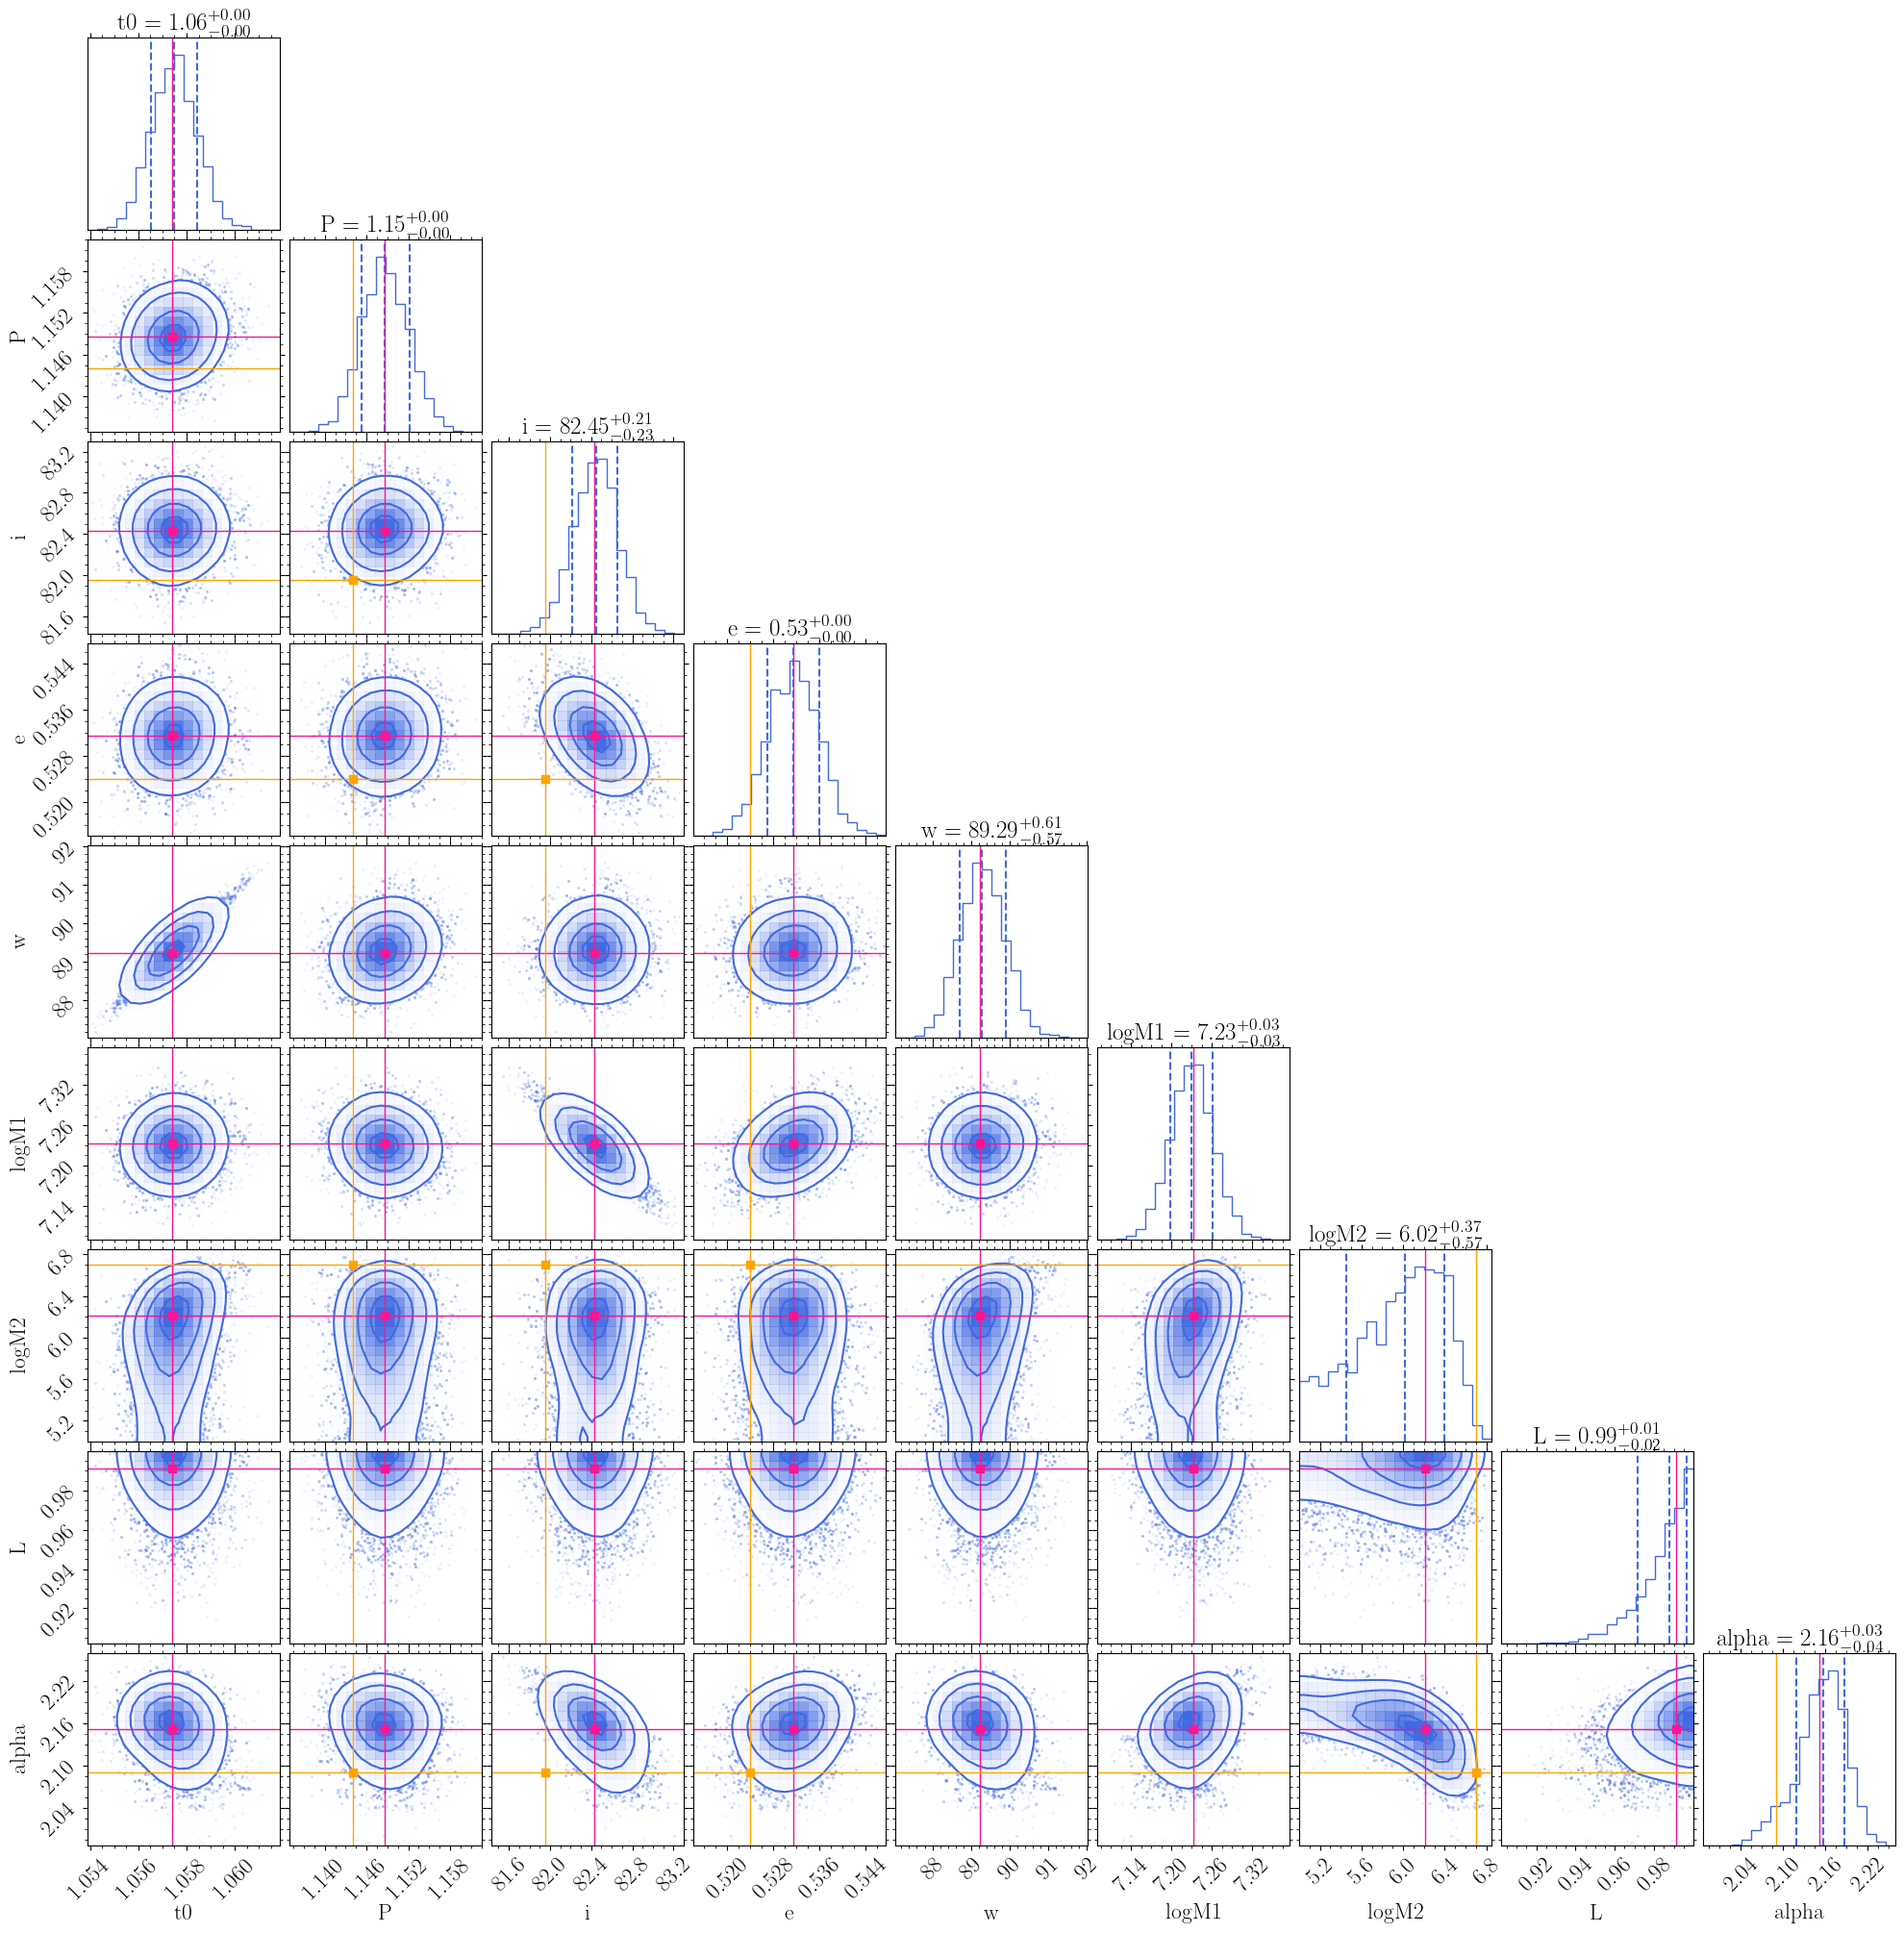

In [19]:
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(fdir / f'{filename}_cornerplot.png', bbox_inches='tight', dpi=200)

Generate the light curve model:

In [20]:
dm = bs.bestfit_model(time, params, result)

Plot best-fit light curve

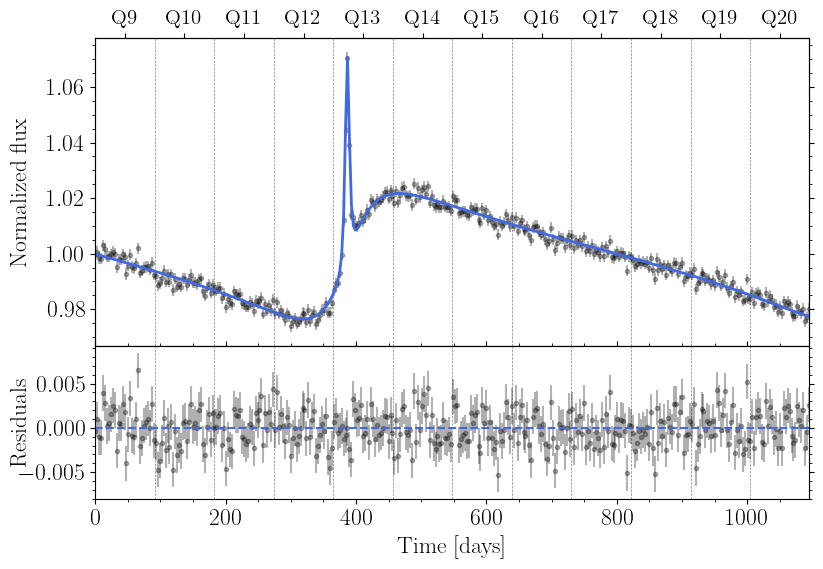

In [21]:
fig, ax = pt.plot_result(df, dm, Q0=9, alpha=0.3, figsize=(8.5, 6));
fig.savefig(fdir / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

---
## 2. With DRW model
---

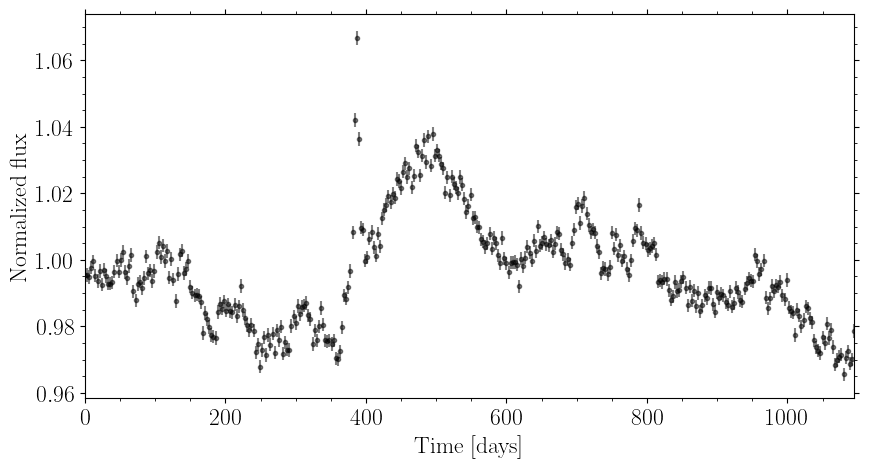

In [6]:
params = smbhb.model_params()
params.seed = 12345
# Initialise model with model parameters
model = smbhb.model(params)
# Generate the light curve model
dm = model.light_curve(time, df=True)
# Create data frame with model time series
dv = pd.DataFrame()
dv['time'] = dm.time
dv['flux'] = dm.flux
# Add some Gaussian noise to to the model
df = dv.copy()
noise_level = 2e-3  # [pp1]
np.random.seed(params.seed)  # Reproducibility
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)
# Arrays to be used for the rest of the analysis
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()
# Plot new noisy light curve
pt.plot_lc(df);

## UltraNest with uniform priors

Define priors  UltraNest + SMBHB:

In [30]:
filename = 'spikey_rednoise_test0'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [70, 90]
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-2e+04  -16070.81 [-16071.7001..-16071.6991]*| it/evals=13942/844008 eff=1.6527% N=400  
# [ultranest] Likelihood function evaluations: 844290
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.61e+04 +- 0.1897
# [ultranest] Effective samples strategy satisfied (ESS = 3060.0, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.53, need <0.5)
# [ultranest]   logZ error budget: single: 0.26 bs:0.19 tail:0.01 total:0.19 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:03:36.611869 [h:mm:ss]

# logZ = -16101.780 +- 0.262
#   single instance: logZ = -16101.780 +- 0.258
#   bootstrapped   : logZ = -16101.847 +- 0.261
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.98% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05417│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▆▅▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │1.06125    1.05767 +- 0.00085
#     P                   : 1.0906│ ▁▁ ▁▁▁▁▁▁▁▂▃▃▄▅▆▆▇▇▇▇▅▄▃▂▂▁▁▁▁▁▁▁▁  ▁ │1.1159    1.1029 +- 0.0028
#     i                   : 81.22 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▆▇▇▇▆▆▄▄▃▂▂▁▁▁▁▁▁ ▁ │83.13     82.25 +- 0.23
#     e                   : 0.5310│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇▇▆▅▆▄▃▃▂▂▁▁▁▁▁▁▁ ▁ │0.5634    0.5472 +- 0.0040
#     w                   : 86.89 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇▇▆▆▅▄▄▂▂▂▁▁▁▁▁▁▁▁ │91.51     89.32 +- 0.56
#     logM1               : 7.069 │ ▁ ▁▁▁▁▁▁▁▂▃▃▄▅▆▇▇▇▇▇▇▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.338     7.200 +- 0.032
#     logM2               : 5.00  │▅▅▆▇▅▆▆▆▇▆▇▇▇▇▆▇▇▇▇▇▇▇▆▅▅▆▄▄▃▃▄▃▃▁▁▁▁▁ │6.84      5.72 +- 0.41
#     L                   : 0.894 │ ▁  ▁▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▂▄▃▄▄▅▅▆▆▇▇▇│1.000     0.982 +- 0.014
#     alpha               : 1.975 │ ▁▁  ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▅▆▇▇▇▆▅▃▃▂▁▁▁▁▁▁▁ │2.254     2.141 +- 0.032

In [93]:
filename = 'spikey_rednoise_test1'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz

In [34]:
filename = 'spikey_rednoise_test2'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [0, 3]
priors.i     = [70, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.9, alpha*1.1]
priors.vz    = vz

In [40]:
filename = 'spikey_rednoise_test3'
priors = bs.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05] # Very sensitive!
priors.P     = [0, 3]
priors.i     = [0, 90]
priors.e     = [e*0.9, e*1.1]
priors.w     = [w*0.9, w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [0, 4]
priors.vz    = vz
# [ultranest] Explored until L=-2e+04  -16070.96 [-16071.7304..-16071.7300]*| it/evals=16840/2278170 eff=0.7393% N=400 
# [ultranest] Likelihood function evaluations: 2278170
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -1.611e+04 +- 0.2278
# [ultranest] Effective samples strategy satisfied (ESS = 3030.3, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.19 to 0.59, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.23 tail:0.01 total:0.23 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:08:45.474082 [h:mm:ss]

# logZ = -16109.025 +- 0.320
#   single instance: logZ = -16109.025 +- 0.291
#   bootstrapped   : logZ = -16109.092 +- 0.320
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.06% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.05367│ ▁ ▁▁▁▁▁▁▁▁▁▂▃▄▅▅▆▇▇▇▇▇▆▄▃▂▂▁▁▁▁▁▁▁▁▁▁ │1.06143    1.05761 +- 0.00083
#     P                   : 1.0899│ ▁  ▁▁▁▁▁▁▁▁▂▃▄▅▆▇▆▇▇▆▆▅▄▃▂▂▁▁▁▁▁▁▁▁ ▁ │1.1156    1.1029 +- 0.0028
#     i                   : 81.26 │ ▁ ▁▁▁▁▁▁▁▁▁▂▂▄▄▅▇▆▇▇▇▇▇▆▅▅▃▃▂▁▁▁▁▁▁▁▁ │83.10     82.24 +- 0.22
#     e                   : 0.5307│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▇▆▄▄▃▃▂▁▁▁▁▁▁▁  ▁ │0.5644    0.5470 +- 0.0040
#     w                   : 86.30 │ ▁    ▁▁▁▁▁▁▁▂▂▄▅▆▆▇▇▇▆▆▅▃▂▂▁▁▁▁▁▁▁▁ ▁ │91.98     89.28 +- 0.55
#     logM1               : 7.072 │ ▁▁▁▁▁▁▁▁▁▂▃▃▄▅▆▆▇▇▇▆▆▅▅▃▂▂▂▁▁▁▁▁▁▁▁ ▁ │7.340     7.201 +- 0.032
#     logM2               : 5.00  │▇▇▇▇▇▇▇▆▇▇▇▅▇▅▆▆▆▆▇▆▇▆▅▇▆▆▅▆▄▄▃▃▃▂▁▁▁▁ │6.81      5.69 +- 0.42
#     L                   : 0.900 │ ▁ ▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▃▃▄▄▅▅▆▇▇▇▇│1.000     0.983 +- 0.014
#     alpha               : 1.962 │ ▁ ▁▁▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▇▅▄▃▂▁▁▁▁▁ │2.241     2.144 +- 0.032

In [11]:
filename = 'spikey_rednoise_test5'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05] # Very sensitive!
priors.P     = [0, 3]
priors.i     = [0, 90]
priors.e     = [0.01, 0.99]  # Lower bound has to be float or UltraNest don't start..
priors.w     = [0.01, 359.99]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1] # Relative sensative
priors.vz    = params.vz

Run UltraNest + SMBHB model

In [12]:
params_input   = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]
params_names   = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
params_wrapped = [False] * len(params_names)

def prior_transform(cube):
    p = cube.copy()
    p[0] = cube[0] * (priors.t0[1]    - priors.t0[0])    + priors.t0[0]
    p[1] = cube[1] * (priors.P[1]     - priors.P[0])     + priors.P[0] 
    p[2] = cube[2] * (priors.i[1]     - priors.i[0])     + priors.i[0] 
    p[3] = cube[3] * (priors.e[1]     - priors.e[0])     + priors.e[0] 
    p[4] = cube[4] * (priors.w[1]     - priors.w[0])     + priors.w[0] 
    p[5] = cube[5] * (priors.logM1[1] - priors.logM1[0]) + priors.logM1[0] 
    p[6] = cube[6] * (priors.logM2[1] - priors.logM2[0]) + priors.logM2[0] 
    p[7] = cube[7] * (priors.L[1]     - priors.L[0])     + priors.L[0] 
    p[8] = cube[8] * (priors.alpha[1] - priors.alpha[0]) + priors.alpha[0] 
    return p
    
def log_likelihood(p):       
    flux_model = smbhb.smbhb(
        time  = time,
        z     = params.z,
        t0    = p[0],
        P     = p[1],
        i     = p[2],
        e     = p[3],
        w     = p[4],
        logM1 = p[5],
        logM2 = p[6],
        L     = p[7],
        alpha = p[8],
        vz    = params.vz,
        tau   = None,
        sigma = None,
        seed  = None
    )
    return -0.5 * np.nansum(((flux_model - flux) / flux_err)**2)

sampler = ReactiveNestedSampler(
    params_names,
    log_likelihood, 
    prior_transform,
    wrapped_params = params_wrapped,
    log_dir        = rdir / filename,
    resume         = 'overwrite',
)

sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(
    nsteps          = 1000,
    max_nsteps      = 1000,
    adaptive_nsteps = 'move-distance',
)

Run UltraNest on our simulated light curve:

In [13]:
# Run nested sampling
tic  = datetime.datetime.now()
result = sampler.run(min_num_live_points=400)
toc  = datetime.datetime.now()
print(f'Execution time: {toc-tic} [h:mm:ss]')
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...


Z=-16158.7(0.00%) | Like=-16129.07..-16080.21 [-16139.4038..-16128.3831] | it/evals=10815/7164134 eff=0.1510% N=400 

SystemError: CPUDispatcher(<function smbhb at 0x7fc00adaff60>) returned a result with an exception set

In [ ]:
# result, sampler = bs.run_ultranest(df, priors, rdir, nsteps=1000, live_points=400)

Make conerplot and compare to input values

In [ ]:
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(fdir / f'{filename}_cornerplot.png', bbox_inches='tight', dpi=200)

Generate the light curve model:

In [ ]:
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model(time, params_model, result)

Plot best-fit light curve

In [ ]:
fig, ax = pt.plot_result(df, dm, Q0=9, alpha=0.3, figsize=(8.5, 6));
fig.savefig(fdir / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

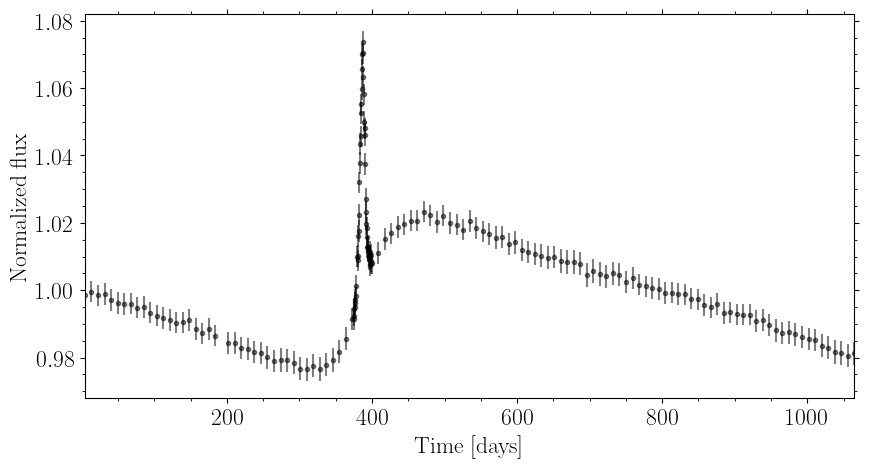

In [9]:
# Generate relativistic Spikey model
params = smbhb.model_params()
params.sigma = 0 
params.seed  = 12345
model = smbhb.model(params)
dm = model.light_curve(time, df=True)
# Load Hu+2020 binned light curve of Spikey 
df = pd.read_csv(ddir / 'data_spikey_kepler_binned_smbhb.csv')
time = df.time.to_numpy()
flux = df.flux.to_numpy()
flux_err = df.flux_err.to_numpy()
# Plot new noisy light curve
pt.plot_lc(df);

In [10]:
filename = 'spikey_kepler_hu2020_test0'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [70, 90]
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-4e+03  782.72 [-3783.4641..-3783.4637]*| it/evals=15504/848846 eff=1.8273% N=400   0 
# [ultranest] Likelihood function evaluations: 849013
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3817 +- 0.2082
# [ultranest] Effective samples strategy satisfied (ESS = 3322.3, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.05 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.21, need <0.5)
# [ultranest]   logZ error budget: single: 0.27 bs:0.21 tail:0.01 total:0.21 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:01:41.203287 [h:mm:ss]

# logZ = -3817.405 +- 0.455
#   single instance: logZ = -3817.405 +- 0.274
#   bootstrapped   : logZ = -3817.366 +- 0.455
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.90% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.06325│ ▁▁▁ ▁▁▁▁▁▁▁▂▂▂▃▃▄▆▆▇▇▇▇▇▆▅▄▄▃▂▂▁▁▁▁▁▁ │1.06552    1.06456 +- 0.00027
#     P                   : 1.115 │ ▁▁▁▁▁▁▁▁▁▁▂▃▃▄▅▇▇▇▇▇▇▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁ │1.201     1.158 +- 0.010
#     i                   : 81.18 │ ▁   ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▅▅▇▇▇▆▇▆▅▃▃▂▂▁▁▁▁▁ │83.72     82.74 +- 0.29
#     e                   : 0.472 │▁▁▁▁▂▂▂▃▃▄▅▆▇▆▇▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │0.548     0.503 +- 0.011
#     w                   : 92.619│ ▁ ▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇│93.093    93.043 +- 0.049
#     logM1               : 7.109 │ ▁ ▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▃▂▁▁▁▁▁▁▁▁    ▁ │7.498     7.283 +- 0.042
#     logM2               : 6.09  │ ▁   ▁▁  ▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▆▄▃▁▁▁▁▁ │7.37      7.00 +- 0.11
#     L                   : 0.9384│ ▁  ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▃▃▃▃▄▅▅▆▆▇▇│1.0000    0.9903 +- 0.0082
#     alpha               : 1.881 │▁▂▂▂▃▄▄▄▅▅▆▆▆▇▇▆▆▆▅▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁ ▁ │2.165     1.982 +- 0.043

In [18]:
filename = 'spikey_kepler_hu2020_test1'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.05]
priors.P     = [params.P*0.95, params.P*1.05]
priors.i     = [0, 90]                          # Changed
priors.e     = [params.e*0.9, params.e*1.1]
priors.w     = [params.w*0.9, params.w*1.1]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.9, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-4e+03  782.47 [-3783.4222..-3783.4210]*| it/evals=16217/999644 eff=1.6229% N=400    
# [ultranest] Likelihood function evaluations: 999825
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3819 +- 0.2124
# [ultranest] Effective samples strategy satisfied (ESS = 3328.7, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.21, need <0.5)
# [ultranest]   logZ error budget: single: 0.28 bs:0.21 tail:0.01 total:0.21 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:02:00.709778 [h:mm:ss]

# logZ = -3819.119 +- 0.396
#   single instance: logZ = -3819.119 +- 0.282
#   bootstrapped   : logZ = -3819.115 +- 0.396
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.95 (should be >1), far enough fraction: 50.85% : fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.06338│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▆▇▇▇▆▅▅▄▃▃▂▁▁▁▁▁ ▁▁▁ │1.06565    1.06455 +- 0.00026
#     P                   : 1.116 │ ▁▁ ▁▁▁▁▁▁▂▂▃▄▅▅▆▇▇▇▇▇▅▅▃▃▂▂▁▁▁▁▁▁▁▁ ▁▁│1.201     1.158 +- 0.010
#     i                   : 81.42 │ ▁  ▁▁▁▁▁▁▁▁▂▂▂▄▄▅▆▇▇▇▇▇▆▆▅▄▃▂▂▁▁▁▁▁ ▁ │83.80     82.72 +- 0.29
#     e                   : 0.472 │▁▁▁▁▁▂▂▃▄▄▅▆▆▇▇▇▇▇▆▆▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁  ▁ │0.550     0.503 +- 0.011
#     w                   : 92.458│ ▁        ▁ ▁   ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▆▇│93.093    93.043 +- 0.050
#     logM1               : 7.092 │ ▁  ▁▁▁▁▁▁▁▂▂▂▄▅▆▆▆▇▆▇▆▆▅▃▃▂▂▁▁▁▁▁▁▁▁▁ │7.467     7.285 +- 0.042
#     logM2               : 5.99  │ ▁▁   ▁▁▁ ▁ ▁▁▁▁▁▁▁▁▁▁▂▂▃▅▆▇▇▇▆▅▃▂▁▁▁▁ │7.38      6.99 +- 0.11
#     L                   : 0.9396│ ▁▁ ▁▁ ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▂▂▂▃▃▄▄▅▅▅▆▆▇▇│1.0000    0.9900 +- 0.0085
#     alpha               : 1.881 │▁▁▁▂▃▃▃▃▄▅▆▇▇▇▇▇▆▆▅▄▄▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁ ▁ │2.165     1.985 +- 0.043

In [40]:
filename = 'spikey_kepler_hu2020_test2'
priors = bs.model_priors()
priors.z     = params.z
priors.t0    = [params.t0*0.95, params.t0*1.1]
priors.P     = [params.P*0.9, params.P*1.3]
priors.i     = [0, 90]
priors.e     = [params.e*0.5, params.e*1.5]
priors.w     = [params.w*0.5, params.w*1.8] # Changed
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [params.alpha*0.5, params.alpha*1.1]
priors.vz    = params.vz
# [ultranest] Explored until L=-3e+03  345.19 [-3345.7911..-3345.7905]*| it/evals=17000/2617955 eff=0.6495% N=400 00    
# [ultranest] Likelihood function evaluations: 2617999
# [ultranest] Writing samples and results to disk ...
# [ultranest] Writing samples and results to disk ... done
# [ultranest]   logZ = -3384 +- 0.2149
# [ultranest] Effective samples strategy satisfied (ESS = 3169.6, need >400)
# [ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <0.50 nat)
# [ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.17 to 0.52, need <0.5)
# [ultranest]   logZ error budget: single: 0.29 bs:0.21 tail:0.01 total:0.22 required:<0.50
# [ultranest] done iterating.
# Execution time: 0:05:24.451312 [h:mm:ss]

# logZ = -3383.510 +- 0.404
#   single instance: logZ = -3383.510 +- 0.292
#   bootstrapped   : logZ = -3383.574 +- 0.404
#   tail           : logZ = +- 0.010
# insert order U test : converged: True correlation: inf iterations
# step sampler diagnostic: jump distance 0.94 (should be >1), far enough fraction: 49.51% : very fishy. Double nsteps and see if fraction and lnZ change)

#     t0                  : 1.0913│ ▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▆▅▅▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁ │1.1106    1.0999 +- 0.0023
#     P                   : 1.178 │ ▁▁▁▁▁▁▁▁▁▂▃▄▅▆▆▇▇▇▆▇▆▄▃▃▂▁▁▁▁▁▁▁▁  ▁▁ │1.369     1.266 +- 0.021
#     i                   : 78.19 │ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁▁▁ │82.20     80.36 +- 0.46
#     e                   : 0.6124│ ▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▇▇▇▇▇▅▅▃▃▂▂▁▁▁▁▁▁▁▁ │0.6906    0.6546 +- 0.0089
#     w                   : 121.69│ ▁ ▁▁▁▁▁▁▁▁▂▂▂▃▅▅▆▆▇▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁ ▁ │130.65    126.29 +- 0.97
#     logM1               : 7.396 │ ▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▇▆▅▄▃▃▂▁▁▁▁▁▁▁▁▁▁ │7.819     7.608 +- 0.049
#     logM2               : 7.515 │ ▁▁▁▁▁▁▁▁▁▁▂▃▃▅▅▇▆▇▇▇▆▆▅▄▄▂▂▁▁▁▁▁▁▁ ▁▁ │8.085     7.798 +- 0.067
#     L                   : 0.842 │ ▁  ▁▁▁▁▁▁▁▂▂▂▃▅▅▆▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁ │0.969     0.909 +- 0.015
#     alpha               : 1.108 │ ▁   ▁▁▁▁▁▁▁▁▁▁▂▂▄▅▆▆▇▇▇▇▆▅▄▃▂▂▁▁▁▁▁ ▁ │1.935     1.590 +- 0.084

In [41]:
params_input   = [params.t0, params.P, params.i, params.e, params.w, params.logM1, params.logM2, params.L, params.alpha]
params_names   = ['t0', 'P', 'i', 'e', 'w', 'logM1', 'logM2', 'L', 'alpha']
params_wrapped = [False] * len(params_names)

def prior_transform(cube):
    p = cube.copy()
    p[0] = cube[0] * (priors.t0[1]    - priors.t0[0])    + priors.t0[0]
    p[1] = cube[1] * (priors.P[1]     - priors.P[0])     + priors.P[0] 
    p[2] = cube[2] * (priors.i[1]     - priors.i[0])     + priors.i[0] 
    p[3] = cube[3] * (priors.e[1]     - priors.e[0])     + priors.e[0] 
    p[4] = cube[4] * (priors.w[1]     - priors.w[0])     + priors.w[0] 
    p[5] = cube[5] * (priors.logM1[1] - priors.logM1[0]) + priors.logM1[0] 
    p[6] = cube[6] * (priors.logM2[1] - priors.logM2[0]) + priors.logM2[0] 
    p[7] = cube[7] * (priors.L[1]     - priors.L[0])     + priors.L[0] 
    p[8] = cube[8] * (priors.alpha[1] - priors.alpha[0]) + priors.alpha[0] 
    return p
    
def log_likelihood(p):       
    flux_model = smbhb.smbhb(
        time  = time,
        z     = params.z,
        t0    = p[0],
        P     = p[1],
        i     = p[2],
        e     = p[3],
        w     = p[4],
        logM1 = p[5],
        logM2 = p[6],
        L     = p[7],
        alpha = p[8],
        vz    = params.vz,
        tau   = None,
        sigma = None,
        seed  = None
    )
    return -0.5 * np.nansum(((flux_model - flux) / flux_err)**2)

sampler = ReactiveNestedSampler(
    params_names,
    log_likelihood, 
    prior_transform,
    wrapped_params = params_wrapped,
    log_dir        = rdir / filename,
    resume         = 'overwrite',
)

sampler.stepsampler = ultranest.stepsampler.RegionSliceSampler(
    nsteps          = 1000,
    max_nsteps      = 1000,
    adaptive_nsteps = 'move-distance',
)

In [42]:
# Run nested sampling
tic  = datetime.datetime.now()
result = sampler.run(min_num_live_points=400)
toc  = datetime.datetime.now()
print(f'Execution time: {toc-tic} [h:mm:ss]')
sampler.print_results()

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+03  345.19 [-3345.7911..-3345.7905]*| it/evals=17000/2617955 eff=0.6495% N=400 00    
[ultranest] Likelihood function evaluations: 2617999
[ultranest] Writing samples and results to disk ...
[ultranest] Writing samples and results to disk ... done
[ultranest]   logZ = -3384 +- 0.2149
[ultranest] Effective samples strategy satisfied (ESS = 3169.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.17 to 0.52, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.21 tail:0.01 total:0.22 required:<0.50
[ultranest] done iterating.
Execution time: 0:05:24.451312 [h:mm:ss]

logZ = -3383.510 +- 0.404
  single instance: logZ = -3383.510 +- 0.292
  bootstrapped   : logZ = -3383.574 +- 0.404
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations
step sampler diagnostic: jum

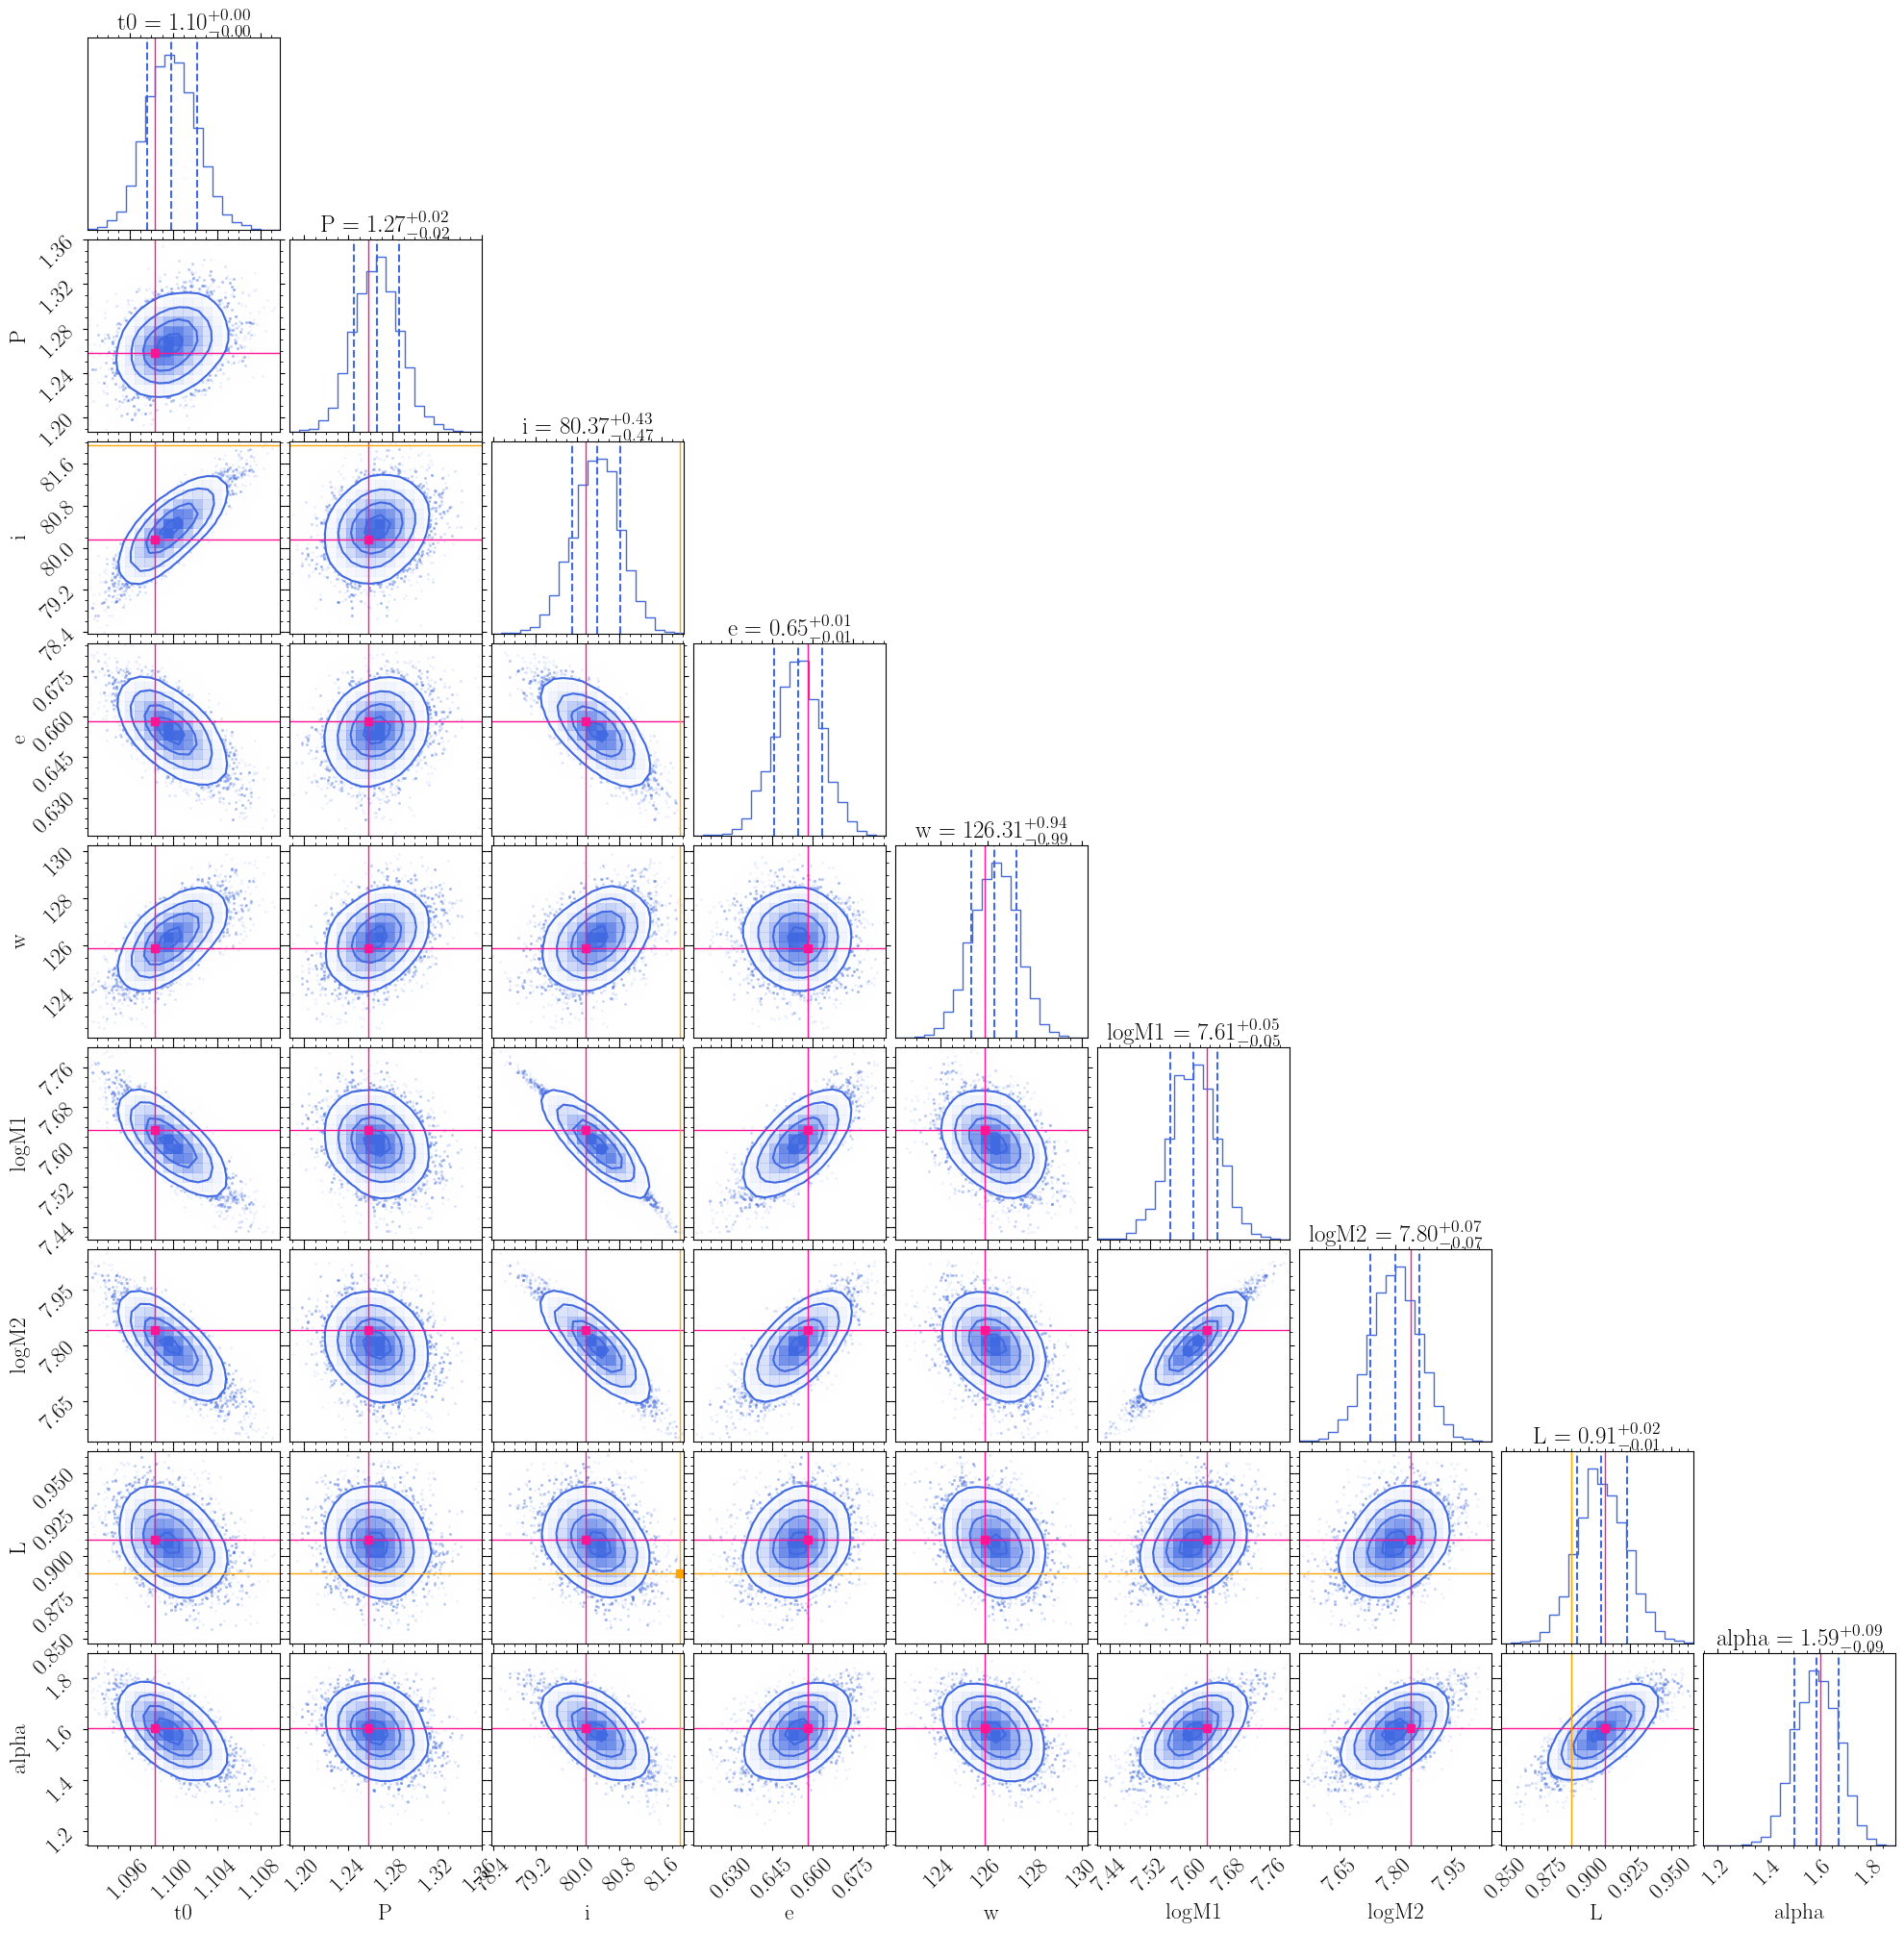

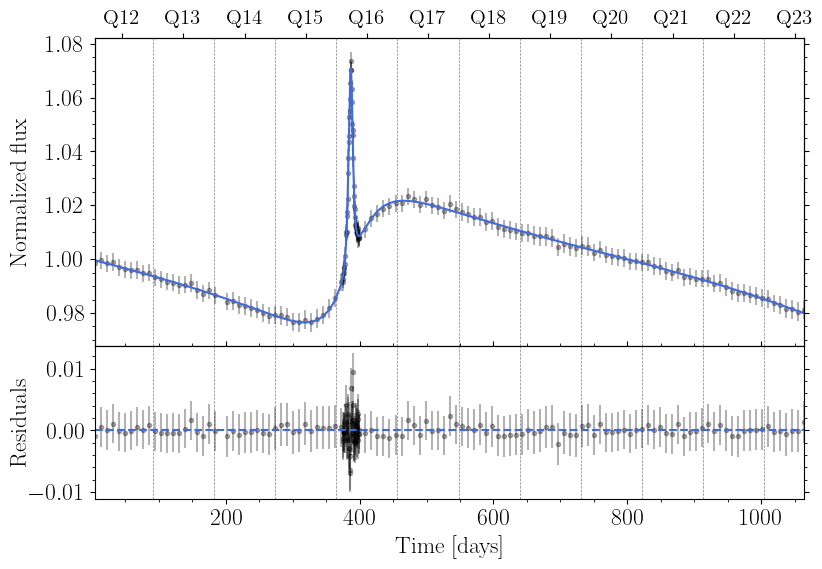

In [43]:
fig = pt.plot_corner(result, bestfit='maximum', values_input=params_input);
fig.savefig(fdir / f'{filename}_cornerplot.png', bbox_inches='tight', dpi=200)
params_model = copy.deepcopy(params)
params_model.sigma = 0
dm = bs.bestfit_model(time, params_model, result)
fig, ax = pt.plot_result(df, dm, Q0=12, alpha=0.3, figsize=(8.5, 6));
fig.savefig(fdir / f'{filename}_bestfit.png', bbox_inches='tight', dpi=200)

---
## 2. PlatoSim light curve of Spikey
---

In [ ]:
t0 = 0.905  # [yr]
t0 * 365.25

Read light curve:

In [ ]:
df = pd.read_feather(rdir / 'lc_spikey_fiducial_1d.ftr')
df.time -= df.time.iloc[0]

Plot light curve:

In [ ]:
lc = LightCurve(df, mode='multi')
lc.plot(time_unit='s', flux_unit='norm', flux_error=True, alpha=0.5);

Run modelfit with UltraNest

In [ ]:
priors = smbhb.model_priors()
priors.z     = z
priors.t0    = [t0*0.9, t0*1.1]
priors.P     = [P*0.8, P*1.2]
priors.i     = [70, 90]
priors.e     = [0, 0.9]
priors.w     = [w*0.7, w*1.3]
priors.logM1 = [5, 11]
priors.logM2 = [5, 11]
priors.L     = [0, 1]
priors.alpha = [alpha*0.5, alpha*1.5] # scipy.stats.norm(alpha, 0.5)
priors.vz    = vz

In [ ]:
result, sampler = smbhb.run_ultranest(df, priors, rdir, nsteps=1000, live_points=400)

Plot best-fit light curve

In [ ]:
fig, ax = smbhb.plot_result(df, result, z, Q0=9, label='Plato observation', alpha=0.3, figsize=(9,7));
# fig.savefig(fdir / f'fig2_bestfitmodel.png', bbox_inches='tight', dpi=200)

Make a pretty corner plot:

In [ ]:
values_input = np.array([t0, P, i, e, w, logM1, logM2, L, alpha])
fig = smbhb.plot_corner(result, bestfit='maximum', values_input=values_input);
# fig.savefig(fdir / f'fig2_cornerplot.png', bbox_inches='tight', dpi=200)